In [1]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Parameters
# -----------------------------
dt = 0.01       # ms
T_equil = 100   # ms
T_sim = 150     # ms

Cm = 1.0        # uF/cm^2
gL = 0.1        # mS/cm^2
gNa = 100.0     # mS/cm^2
gKdr = 20       # mS/cm^2
gKHT = 500      # mS/cm^2

EL = -65.0      # mV, leak reversal potential
ENa = 55.0      # mV
EK = -80.0      # mV
EE = 0.0        # mV, excitatory synaptic reversal potential
EI = -75.0      # mV, inhibitory synaptic reversal potential

tau_w = 1.0     # ms, time constant for H-current gating variable
tau_E = 5.0     # ms
tau_I = 5.0     # ms


I_values = np.arange(10.0, 100.0 + 0.1, 5.0)


In [2]:

def I_ext_time(t, I_amp):
    """
    Generates a current pulse.
    Current injection starts at 50 ms and stops at 100 ms.
    """
    if 50.0 <= t < 100.0:
        return I_amp
    return 0.0

def safe_rate(x, scale=10.0):
    """
    Computes x / (1 - exp(-x/scale)) safely at the limit x -> 0.
    Limit as x -> 0 is scale.
    """
    if abs(x) < 1e-8:
        return scale
    return x / (1.0 - np.exp(-x / scale))


def hvcI_rhs(t, y, I_amp):
    """
    Right-hand side for HVC(I) single-compartment model equations.

    y = [V, m, h, n, w, gE, gI]
    """

    # V is membrane potential, m/h/n are gating variables for Na/K channels, w is the gating variable for the H-current, and gE/gI are the excitatory/inhibitory synaptic conductances.
    V, m, h, n, w, gE, gI = y
    
    Iext = I_ext_time(t, I_amp)

    # -----------------------------
    # Ionic currents
    # -----------------------------
    IL = gL * (EL - V)
    INa = gNa * m**3 * h * (ENa - V)
    IKdr = gKdr * n**4 * (EK - V)
    IKHT = gKHT * w * (EK - V)

    # -----------------------------
    # Synaptic currents
    # -----------------------------
    IExc = gE * (EE - V)
    IInh = gI * (EI - V)

    # Voltage equation
    dVdt = (IL + INa + IKdr + IKHT + IExc + IInh + Iext) / Cm

    # -----------------------------
    # Gating kinetics
    # -----------------------------

    # sodium activation m
    alpha_m = safe_rate(V + 22.0, scale=10.0)
    beta_m = 40.0 * np.exp(-(V + 47.0) / 18.0)

    # sodium inactivation h
    alpha_h = 0.7 * np.exp(-(V + 34.0) / 20.0)
    beta_h = 10.0 / (1.0 + np.exp(-(V + 4.0) / 10.0))

    # delayed-rectifier potassium activation n
    alpha_n = 0.15 * safe_rate(V + 15.0, scale=10.0)
    beta_n = 0.2 * np.exp(-(V + 25.0) / 80.0)

    dmdt = alpha_m * (1.0 - m) - beta_m * m
    dhdt = alpha_h * (1.0 - h) - beta_h * h
    dndt = alpha_n * (1.0 - n) - beta_n * n

    # high-threshold potassium activation w
    w_inf = 1.0 / (1.0 + np.exp(-V / 5.0))
    dwdt = (w_inf - w) / tau_w

    # synaptic conductance decay
    dgEdt = -gE / tau_E
    dgIdt = -gI / tau_I
   
    
    return np.array([dVdt, dmdt, dhdt, dndt, dwdt, dgEdt, dgIdt])    


def rk4_step(t, y, dt, I_amp):
    """
    One fourth-order Runge-Kutta step.
    """
    k1 = hvcI_rhs(t, y, I_amp)
    k2 = hvcI_rhs(t + dt/2, y + dt*k1/2, I_amp)
    k3 = hvcI_rhs(t + dt/2, y + dt*k2/2, I_amp)
    k4 = hvcI_rhs(t + dt, y + dt*k3, I_amp)

    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)


In [3]:
def initial_conditions():
    V0 = EL

    alpha_m = safe_rate(V0 + 22.0, scale=10.0)
    beta_m = 40.0 * np.exp(-(V0 + 47.0) / 18.0)
    m0 = alpha_m / (alpha_m + beta_m)

    alpha_h = 0.07 * np.exp(-(V0 + 34.0) / 20.0)
    beta_h = 10.0 / (1.0 + np.exp(-(V0 + 4.0) / 10.0))
    h0 = alpha_h / (alpha_h + beta_h)

    alpha_n = 0.15 * safe_rate(V0 + 15.0, scale=10.0)
    beta_n = 0.2 * np.exp(-(V0 + 25.0) / 80.0)
    n0 = alpha_n / (alpha_n + beta_n)

    w0 = 1.0 / (1.0 + np.exp(-V0 / 5.0))

    gE0 = 0.0
    gI0 = 0.0

    return np.array([V0, m0, h0, n0, w0, gE0, gI0])

def equilibrate():
    """ 
    runs the simulation for a period of time (T_equil) with zero external current (I_amp=0).
    To find the true "resting state" of the neuron as the starting point for the subsequent simulations.
    """ 
    y = initial_conditions()
    t = 0.0

    for _ in range(int(T_equil / dt)):
        y = rk4_step(t, y, dt, I_amp=0.0)
        t += dt

    return y

def simulate(I_amp, y0):
    """ 
    Simulates the model for a given external current amplitude (I_amp) and initial conditions (y0).
    """
    t_arr = np.arange(0.0, T_sim + dt, dt)
    y_arr = np.zeros((len(t_arr), len(y0)))

    y = y0.copy()

    for i, t in enumerate(t_arr):
        y_arr[i] = y
        y = rk4_step(t, y, dt, I_amp)

    V = y_arr[:, 0]
    return t_arr, V, y_arr

def count_spikes(t, V, threshold=0.0, tmin=0.0, tmax=None, refractory_ms=2.0):
    """
    Counts upward crossings of threshold by V during tmin to tmax.
    """
    
    if tmax is None:
        tmax = t[-1]

    crossings = np.where(
        (V[:-1] < threshold) &
        (V[1:] >= threshold) &
        (t[1:] >= tmin) &
        (t[1:] < tmax)
    )[0]

    spike_times = []
    last_spike = -np.inf

    for idx in crossings:
        spike_t = t[idx + 1]

        if spike_t - last_spike >= refractory_ms:
            spike_times.append(spike_t)
            last_spike = spike_t

    spike_times = np.array(spike_times)

    return len(spike_times), spike_times

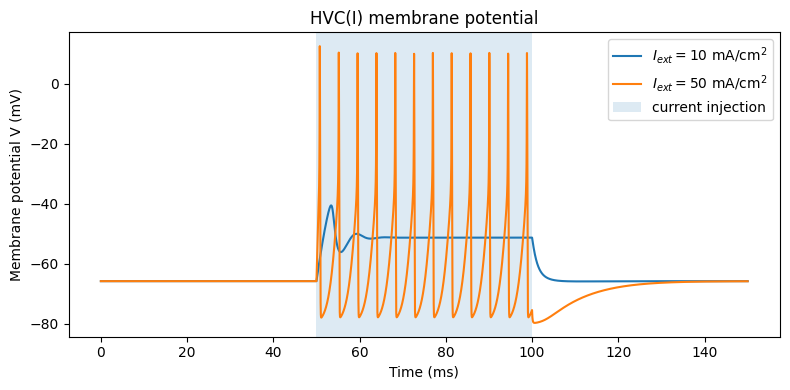

In [4]:
y_eq = equilibrate()

plt.figure(figsize=(8, 4))

for I_amp in [10.0, 50.0]:
    t, V, y_all = simulate(I_amp, y_eq)
    plt.plot(t, V, label=fr"$I_{{ext}} = {I_amp:.0f}$ mA/cm$^2$")

plt.axvspan(50, 100, alpha=0.15, label="current injection")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("HVC(I) membrane potential")
plt.legend()
plt.tight_layout()

plt.savefig("hvcI_voltage_traces.png", dpi=300)
plt.show()

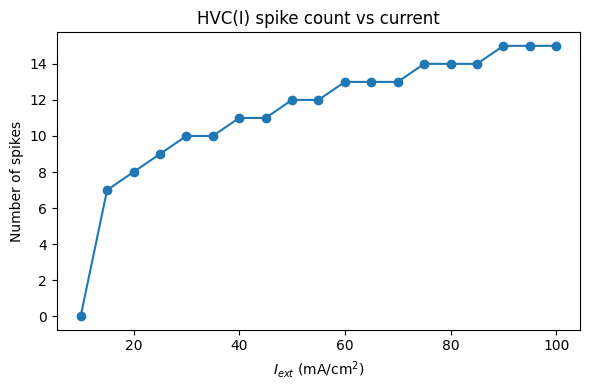

In [7]:
I_values = np.arange(10.0, 100.0 + 0.1, 5.0)
spike_counts = []

for I_amp in I_values:
    t, V, y_all = simulate(I_amp, y_eq)
    n_spikes, _ = count_spikes(t, V, threshold=0.0, tmin=50.0, tmax=100.0)
    spike_counts.append(int(n_spikes))

spike_counts = np.array(spike_counts, dtype=int)

plt.figure(figsize=(6, 4))
plt.plot(I_values, spike_counts, "o-")
plt.xlabel(r"$I_{ext}$ (mA/cm$^2$)")
plt.ylabel("Number of spikes")
plt.title("HVC(I) spike count vs current")
plt.tight_layout()
plt.savefig("HVC_spike_count_vs_current", dpi=300)

plt.show()

In [ ]:
T_noise = 500.0       # ms
fnoise_E = 500.0      # Hz
fnoise_I = 500.0      # Hz

GE_noise = 0.5        # mS/cm^2
GI_noise = 0.5        # mS/cm^2


def generate_poisson_times(rate_Hz, T_ms):
    """
    Generates event times for a Poisson process using exponential inter-event intervals.
    During the simulation, synaptic conductances gE and gI are increased by random andom fraction of GE_noise or GI_noise when the current time reaches one of those event times.
    """
    
    rate_per_ms = rate_Hz / 1000.0  # Convert rate from Hz to events/ms

    times = []
    t = 0.0

    while t < T_ms:
        # inverse-CDF sampling for exponential distribution:
        # interval = -ln(1-u)/rate, where u is a uniform random number in (0, 1).
        u = np.random.rand()
        interval = -np.log(1.0 - u) / rate_per_ms

        t += interval

        if t < T_ms:
            times.append(t)

    return np.array(times)


def simulate_noisy_HVCI(seed=1):
    """
    Simulate HVC(I) with Iext = 0 and random conductance noise.
    
    Noise events:
        gE -> gE + rand * GE_noise
        gI -> gI + rand * GI_noise
        where rand is a random number in [0, 1] drawn independently for each event.
    """
    # Set random seed for reproducibility
    np.random.seed(seed)

    # start from equilibrated noiseless initial condition
    y = equilibrate()

    # empty array to store all the dynamical variables at every time step``
    t_arr = np.arange(0.0, T_noise + dt, dt)
    y_arr = np.zeros((len(t_arr), len(y)))

    # generate independent Poisson event times
    E_times = generate_poisson_times(fnoise_E, T_noise)
    I_times = generate_poisson_times(fnoise_I, T_noise)

    E_index = 0
    I_index = 0

    # this loop runs the simulation and adds noise events to gE and gI at the appropriate times
    for i, t in enumerate(t_arr):
        # add excitatory noise spikes in gE during E_times
        while E_index < len(E_times) and E_times[E_index] <= t:
            y[5] += np.random.rand() * GE_noise   
            E_index += 1

        # add inhibitory noise spikes in gI during I_times
        while I_index < len(I_times) and I_times[I_index] <= t:
            y[6] += np.random.rand() * GI_noise  
            I_index += 1

        y_arr[i] = y

        # Iext = 0
        y = rk4_step(t, y, dt, I_amp=0.0)

    V = y_arr[:, 0]

    return t_arr, V, y_arr, E_times, I_times

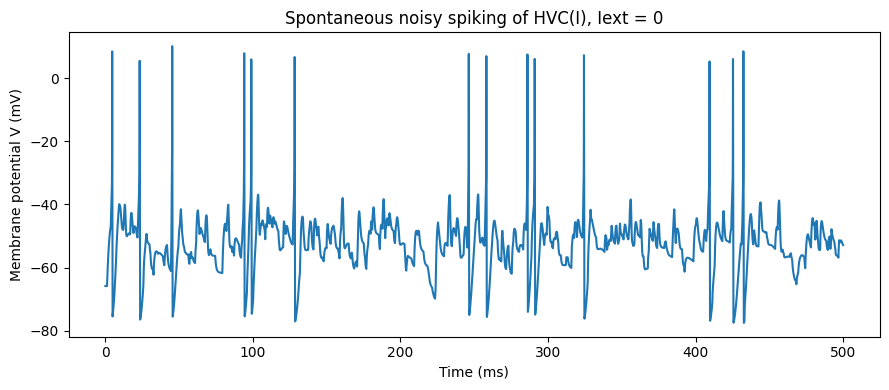

In [16]:
t_noise, V_noise, y_noise, E_times, I_times = simulate_noisy_HVCI(seed=1)

plt.figure(figsize=(9, 4))
plt.plot(t_noise, V_noise)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential V (mV)")
plt.title("Spontaneous noisy spiking of HVC(I), Iext = 0")
plt.tight_layout()
plt.savefig("hvcI_noisy_voltage_trace.png", dpi=300)
plt.show()

In [12]:
n_spikes_noise, spike_times_noise  = count_spikes(
    t_noise,
    V_noise,
    threshold=0.0
)

spontaneous_rate_Hz = n_spikes_noise / (T_noise / 1000.0)

print("Spike times:", spike_times_noise)
print("Number of spontaneous spikes:", n_spikes_noise)
print("Spontaneous firing rate:", spontaneous_rate_Hz, "Hz")

Spike times: [  4.58  23.21  45.25  94.05  98.86 128.25 246.26 258.18 286.02 290.94
 324.34 409.47 425.34 432.38]
Number of spontaneous spikes: 14
Spontaneous firing rate: 28.0 Hz
